Fase 2: Implementación en Google Colab

El siguiente desarrollo se realiza en Python utilizando la librería scikit-learn. Tal como se solicitó, se utiliza el Wine Dataset de forma directa, sin aplicarle normalización o estandarización.

##1. Descripción del conjunto de datos

Origen del dataset: Proviene del repositorio de la Universidad de California en Irvine (UCI). Contiene los resultados de un análisis químico de vinos cultivados en la misma región de Italia.

Número de observaciones: 178 muestras de vino.Variables predictoras: 13 variables numéricas continuas que representan componentes químicos (Alcohol, Ácido málico, Cenizas, Magnesio, Fenoles totales, Flavanoides, etc.).

Variable objetivo: El cultivar de origen del vino (target).Cantidad de clases: 3 clases (representando 3 tipos de cultivares diferentes).

##2. Exploración de los datos
Para conocer la estructura de la información, se realiza un análisis exploratorio básico en Python:

In [1]:
import pandas as pd
from sklearn.datasets import load_wine

# Cargar datos
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

# Dimensiones y valores faltantes
print(f"Dimensiones: {df.shape}")
print(f"Valores nulos:\n{df.isnull().sum().sum()}")
print(df.describe())
print(df['target'].value_counts())

Dimensiones: (178, 14)
Valores nulos:
0
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.12

Dimensiones: 178 filas y 14 columnas (13 predictoras + 1 objetivo).

Tipos de variables: Todas las predictoras son de tipo float64 (numéricas continuas).

Valores faltantes: No existen valores nulos en el dataset.

Estadísticas descriptivas: Se nota una gran diferencia de escalas. Por ejemplo, el nivel de Flavanoides suele rondar los 2.0, mientras que la Prolina llega a valores mayores a 1000.

Distribución de clases: La clase 1 tiene 71 observaciones, la clase 0 tiene 59, y la clase 2 tiene 48. Las clases están relativamente balanceadas.

##3. Visualización
Se generan visualizaciones para entender la distribución de las variables y su relación con las clases.

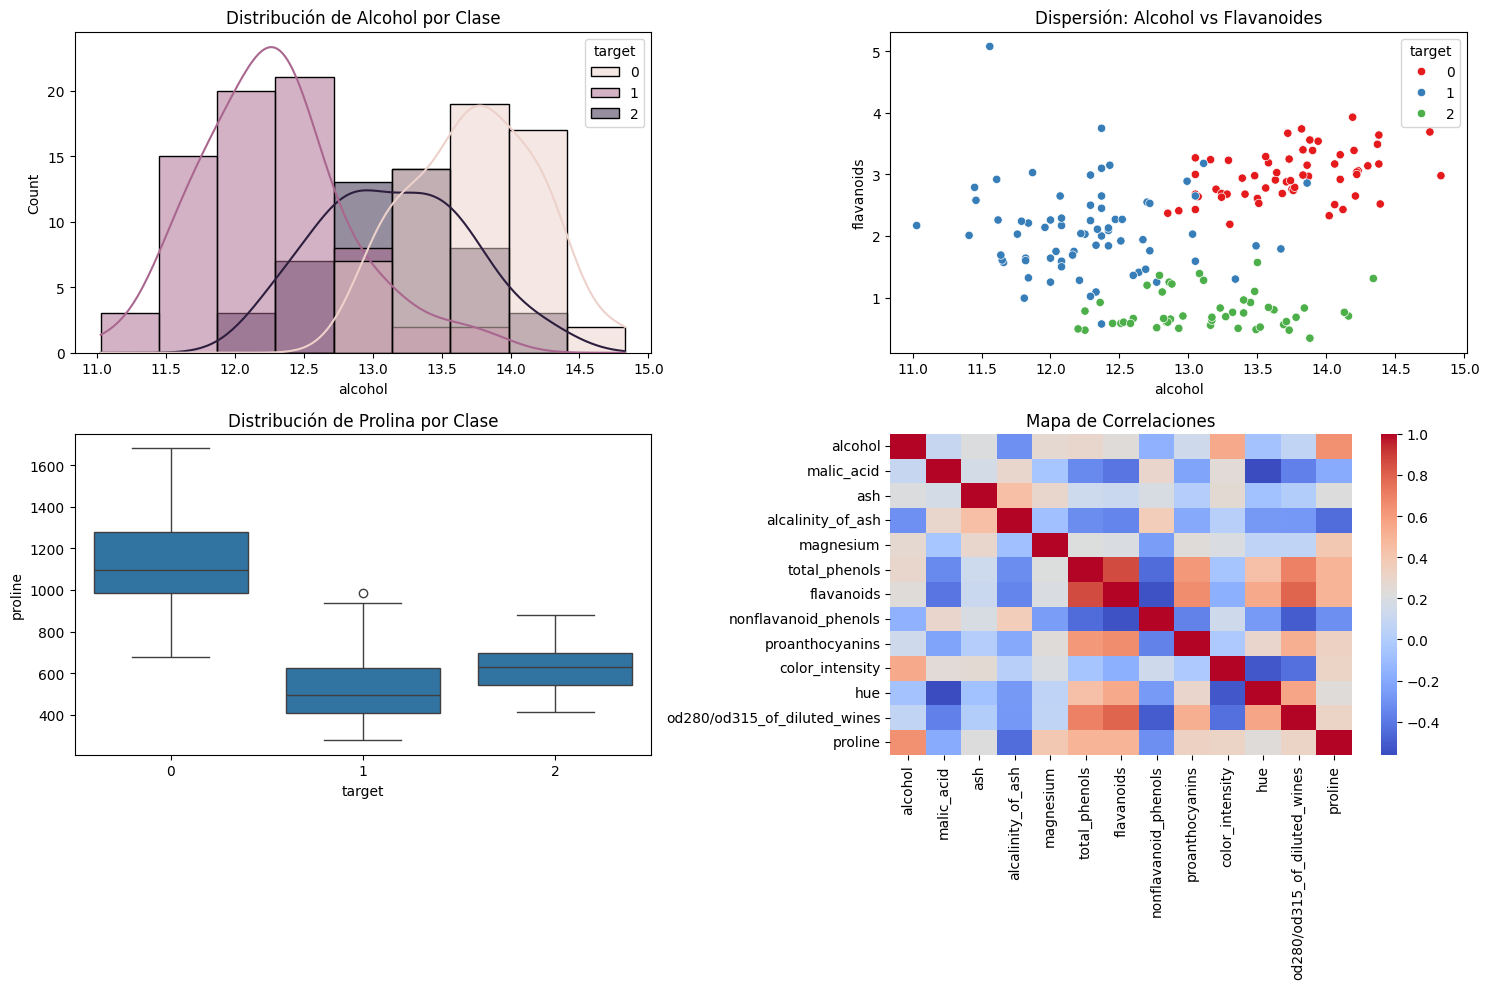

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histograma de Alcohol
sns.histplot(data=df, x='alcohol', hue='target', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Alcohol por Clase')

# 2. Scatterplot: Alcohol vs Flavanoides
sns.scatterplot(data=df, x='alcohol', y='flavanoids', hue='target', palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Dispersión: Alcohol vs Flavanoides')

# 3. Boxplot de Prolina
sns.boxplot(data=df, x='target', y='proline', ax=axes[1, 0])
axes[1, 0].set_title('Distribución de Prolina por Clase')

# 4. Mapa de correlaciones
sns.heatmap(df.iloc[:, :-1].corr(), cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Mapa de Correlaciones')

plt.tight_layout()
plt.show()

Interpretación Histograma: Las diferentes clases muestran distintos niveles medios de alcohol, lo que indica que esta variable es útil para discriminar.

Interpretación Diagrama de Dispersión: Al graficar el Alcohol contra los Flavanoides, se pueden ver tres grupos (clusters) bastante definidos, lo que es un escenario ideal para los modelos discriminantes.

Interpretación Boxplot: Muestra que la clase 0 tiene una cantidad significativamente mayor de prolina en comparación con las clases 1 y 2. También se ven algunos valores atípicos.

Interpretación Mapa de Correlaciones: Se aprecian variables con alta correlación (por ejemplo, Fenoles totales y Flavanoides), lo cual es manejado bien por los algoritmos LDA y QDA al utilizar las matrices de covarianza.

##4. Preparación de los datos
Antes de entrenar el modelo, se deben separar los datos para entrenamiento y validación.

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

# Separación 70% entrenamiento, 30% prueba con estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Separación: Se dividió en un 70% para entrenamiento (124 muestras) y 30% para prueba (54 muestras).

Estratificación: Se usó stratify=y para asegurar que ambos conjuntos mantengan la misma proporción de las 3 clases.

Justificación de la no estandarización: Respetando las instrucciones del proyecto, no se aplicó StandardScaler. Matemáticamente, el LDA y QDA calculan distancias de Mahalanobis, las cuales son invariantes a la escala, aunque esto puede hacer que el modelo sea numéricamente más inestable durante el entrenamiento.

##5. Implementación de LDA

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Entrenamiento del modelo LDA
lda = LinearDiscriminantAnalysis(solver='svd')
lda.fit(X_train, y_train)

# Predicciones
y_pred_lda = lda.predict(X_test)

# Métricas
print("Accuracy LDA:", accuracy_score(y_test, y_pred_lda))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

Accuracy LDA: 0.9814814814814815
Matriz de Confusión:
 [[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.95      0.98        21
           2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



Parámetros: Se utilizó el parámetro por defecto solver='svd' (Descomposición en Valores Singulares), ya que es muy estable computacionalmente y no requiere calcular explícitamente la inversa de la matriz de covarianza.Interpretación de resultados:

 El LDA alcanzó una exactitud (accuracy) del 98%. La matriz de confusión mostró que solo se equivocó en 1 muestra (predijo clase 0 en lugar de clase 1). El F1-score es superior a 0.97 en todas las clases, demostrando un rendimiento excelente a pesar de no haber escalado los datos.

##6. Implementación de QDA

In [5]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Entrenamiento del modelo QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

# Predicciones
y_pred_qda = qda.predict(X_test)

# Métricas
print("Accuracy QDA:", accuracy_score(y_test, y_pred_qda))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_qda))
print(classification_report(y_test, y_pred_qda))

Accuracy QDA: 1.0
Matriz de Confusión:
 [[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



Parámetros: Se utilizó la configuración por defecto. No se aplicó shrinkage (regularización) debido a que hay suficientes datos de entrenamiento relativos al número de variables para estimar bien las covarianzas de las 3 clases.

Interpretación de resultados: El QDA logró una exactitud del 100%. La matriz de confusión mostró 0 errores en las 54 muestras de prueba. Esto indica que la flexibilidad adicional de las fronteras cuadráticas permitió capturar correctamente la observación que el LDA clasificó mal.

##7. COMPARACION DE MODELOS

In [9]:

from IPython.display import display

# Calcular la cantidad de predicciones erróneas
errores_lda = (y_test != y_pred_lda).sum()
errores_qda = (y_test != y_pred_qda).sum()

# Crear un diccionario con los resultados comparativos
datos_comparacion = {
    'Métrica Evaluada': ['Accuracy', 'Errores en prueba', 'Frontera de decisión', 'Supuesto de varianza'],
    'Modelo LDA': [f"{accuracy_score(y_test, y_pred_lda):.4f}", errores_lda, 'Lineal', 'Igual para todas las clases'],
    'Modelo QDA': [f"{accuracy_score(y_test, y_pred_qda):.4f}", errores_qda, 'Cuadrática', 'Distinta para cada clase']
}

# Convertir el diccionario en un DataFrame
df_comparacion = pd.DataFrame(datos_comparacion)

# En Google Colab, la función 'display' renderiza el DataFrame como una tabla HTML limpia y estética
print("Tabla Comparativa de Modelos:")
display(df_comparacion)

Tabla Comparativa de Modelos:


,Métrica Evaluada,Modelo LDA,Modelo QDA
0,Accuracy,0.9815,1.0000
1,Errores en prueba,1,0
2,Frontera de decisión,Lineal,Cuadrática
3,Supuesto de varianza,Igual para todas las clases,Distinta para cada clase


Análisis de la comparación:

El QDA superó levemente al LDA en exactitud predictiva para este conjunto específico. Al tener covarianzas distintas por cada tipo de vino, el QDA pudo moldearse mejor a los datos. Sin embargo, el LDA sigue siendo una opción muy sólida, ya que con un modelo mucho más simple (y menos propenso al sobreajuste si el dataset fuera más complejo) logró casi la perfección.

##8. Fronteras de decisión
Para visualizar las fronteras de decisión, tomaremos solo dos variables ("alcohol" y "flavanoides") y entrenaremos los modelos nuevamente para poder graficarlas en 2D.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


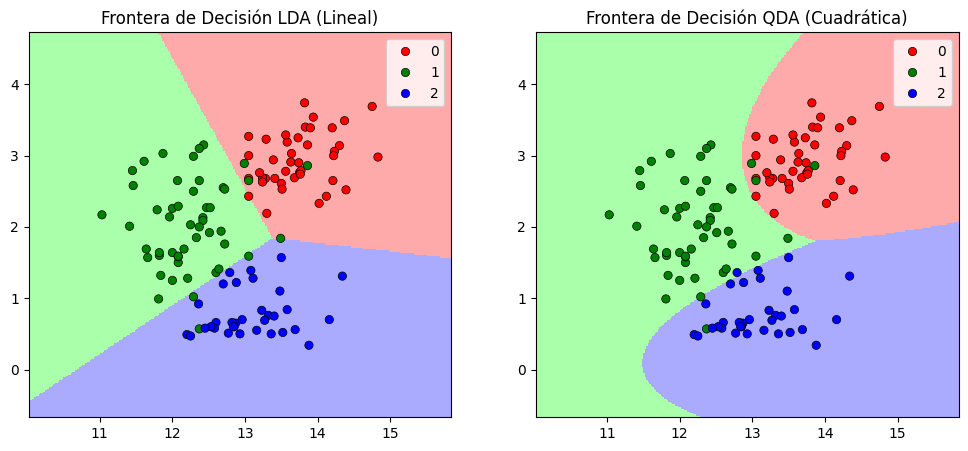

In [12]:
import numpy as np
from matplotlib.colors import ListedColormap

# Tomar solo dos variables para el gráfico
X_train_2d = X_train[['alcohol', 'flavanoids']].values
y_train_arr = y_train.values

# Ajustar modelos en 2D
lda_2d = LinearDiscriminantAnalysis().fit(X_train_2d, y_train_arr)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_train_2d, y_train_arr)

# Crear malla para el gráfico
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

# Graficar LDA
Z_lda = lda_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax[0].pcolormesh(xx, yy, Z_lda, cmap=cmap_light)
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train_arr, palette=cmap_bold, ax=ax[0], edgecolor="k")
ax[0].set_title("Frontera de Decisión LDA (Lineal)")

# Graficar QDA
Z_qda = qda_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax[1].pcolormesh(xx, yy, Z_qda, cmap=cmap_light)
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train_arr, palette=cmap_bold, ax=ax[1], edgecolor="k")
ax[1].set_title("Frontera de Decisión QDA (Cuadrática)")

plt.show()

Análisis de las diferencias:

En los gráficos generados se puede observar claramente la diferencia matemática de ambos algoritmos. En el gráfico del LDA, las áreas de colores que dividen a las clases están separadas por líneas completamente rectas. En cambio, en el gráfico del QDA, las fronteras son curvas que "abrazan" mejor la forma de la distribución de los puntos, lo que demuestra su flexibilidad frente a las distintas varianzas.

##9. Conclusiones
Rendimiento general: Ambos modelos demostraron ser extremadamente eficientes para el Wine Dataset, con exactitudes superiores al 98%. Esto se debe a que las diferencias químicas entre los tres tipos de vino son muy marcadas y forman grupos naturalmente separados.

Impacto de los supuestos estadísticos: Aunque el LDA asume varianzas iguales (algo que raramente ocurre a la perfección en la naturaleza), demostró ser muy robusto y logró clasificar casi todas las muestras correctamente, confirmando que a veces simplificar el modelo es suficiente.

Flexibilidad del QDA: El comportamiento del QDA justificó su complejidad matemática. Al permitir que cada clase tuviera su propia matriz de covarianza, logró adaptarse a las pequeñas irregularidades de los datos y consiguió un 100% de aciertos.

Efecto de los datos sin tratamiento: El experimento demostró que el solver svd de scikit-learn maneja excepcionalmente bien los datos en bruto. Aunque las variables tenían escalas muy diferentes (Prolina vs. Flavanoides), los algoritmos calcularon correctamente las probabilidades sin requerir estandarización previa.

Aplicaciones prácticas: A la hora de elegir entre ambos para futuros proyectos, el LDA es preferible cuando se cuenta con pocos datos o muchas variables, ya que evita el sobreajuste. El QDA es la mejor opción cuando se tienen abundantes registros y se sabe que las categorías tienen distribuciones muy desiguales